In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.weightstats import DescrStatsW
import matplotlib.patches as patches

plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [6]:
total = data.PWGTP.sum()
data.sort_values(by='inc2024', inplace=True)
data['pct'] = data.PWGTP.cumsum() / total

In [34]:
decile_breaks = np.arange(0.1, 1.0, 0.1)
five_breaks = np.arange(0.05, 1.0, 0.1)
d = DescrStatsW(data.inc2024, weights=data.PWGTP)
median = d.quantile(0.5)
deciles = d.quantile(decile_breaks)
fives = d.quantile(five_breaks)
quartiles = d.quantile([0.25, 0.75])

<>:23: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:23: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
/var/folders/3n/v6kbxqb94b92ys1nm0gbhrvm0000gn/T/ipykernel_11549/2666998244.py:23: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  s=f'\$1.9M$\longrightarrow$',


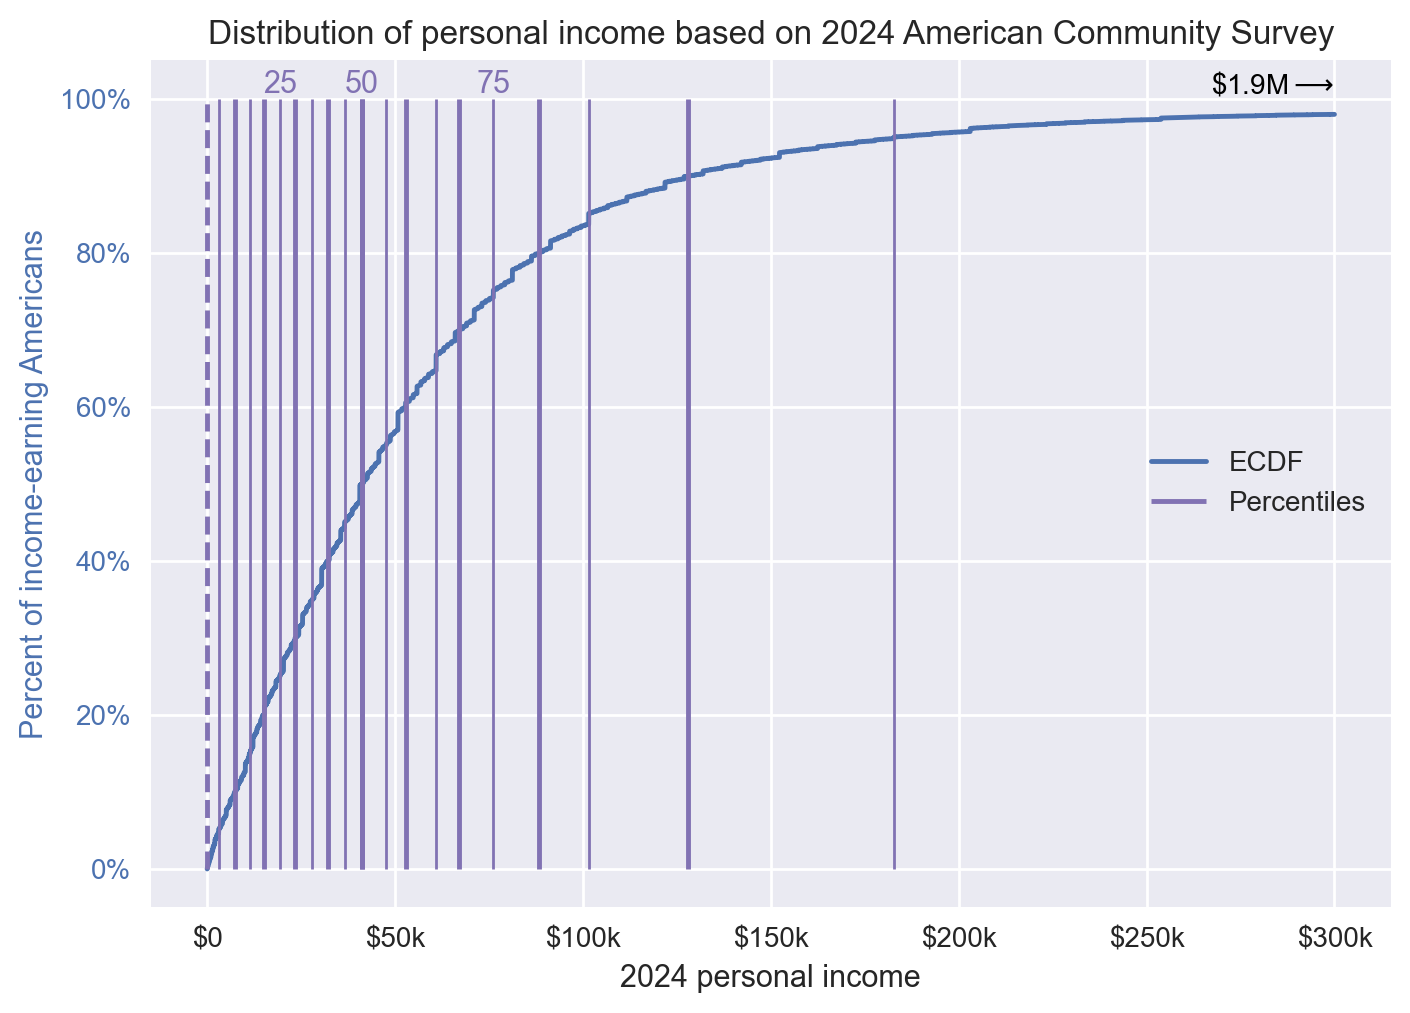

In [71]:
limit = 300_000
subset = data[data.inc2024 < limit]
plt.plot(subset.inc2024, subset.pct, label='ECDF')

plt.vlines(deciles, ymin=0, ymax=1, color='#8172B3', label='Percentiles')
plt.vlines(median, ymin=0, ymax=1, color='#8172B3')
plt.vlines(fives, ymin=0, ymax=1, color='#8172B3', linewidth=1)
plt.vlines([data.inc2024.min()], ymin=0, ymax=1, color='#8172B3', linestyle='dashed')

plt.text(y=1, x=list(median)[0],
    s=f'50',
    ha='center', va='bottom',
    color='#8172B3', fontsize=11)
plt.text(y=1, x=list(quartiles)[0],
    s=f'25',
    ha='center', va='bottom',
    color='#8172B3', fontsize=11)
plt.text(y=1, x=list(quartiles)[1],
    s=f'75',
    ha='center', va='bottom',
    color='#8172B3', fontsize=11)
plt.text(y=1, x=300_000,
    s=f'\$1.9M$\longrightarrow$',
    ha='right', va='bottom',
    color='black', fontsize=10)

plt.legend(loc='center right')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}k' if x != 0 else '$0'))
plt.xlabel('2024 personal income')
plt.title('Distribution of personal income based on 2024 American Community Survey')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.ylabel('Percent of income-earning Americans', color='#4C72B0')
plt.gca().tick_params(axis='y', colors='#4C72B0')

plt.show()

In [57]:
data.max()

PWGTP            2300
ADJINC        1015250
AGEP               96
PINCP       1945000.0
OCCP           9920.0
SOCP           999920
inc2024    1974661.25
pct               1.0
dtype: object